# 01  Préparation détaillée : construire les variables sans fuite temporelle

Ce notebook déroule **pas à pas** la préparation des ventes : chaque traitement est montré, commenté et contrôlé dans sa propre cellule. Le module `src/preparation_03.py` applique exactement la même recette, sous la forme d'une classe `fit`/`transform` réutilisable.

**Deux niveaux de lecture du même traitement :** ici le détail, dans `src/` la version industrialisée. Ce n'est pas une affirmation en l'air  `tests/test_coherence_notebooks.py` exécute les cellules de ce notebook sur des données synthétiques et vérifie que le tableau produit est numériquement identique à celui de `Preparation03`.

La contrainte qui structure tout le notebook : les ventes sont séparées **chronologiquement** dès la deuxième cellule, et toute statistique apprise  médianes, fréquences, catégories rares, règles d'absence  l'est **sur le seul apprentissage**. Les ventes de 2012 sont écartées avant même l'exploration.

**Parcours :**

1. Préparation commune : chargement, typage, valeurs manquantes, spécifications techniques, bornes.
2. Méthode A  toute absence catégorielle devient `Missing`.
3. Méthode B  les absences quasi systématiques dans une famille reçoivent un libellé distinct.
4. Split temporel et statistiques apprises sur l'apprentissage.
5. Construction de X et y.
6. Export vers `02 - Experiences.ipynb`.

Exécuter les cellules dans l'ordre. Pour la fenêtre de confirmation, régler `FENETRE = "confirmation"` en tête et tout réexécuter.

## 1. Préparation commune aux deux méthodes

Tout ce qui suit, jusqu'à la copie en deux DataFrames, est indépendant du choix A/B : les deux méthodes partiront donc des mêmes lignes et des mêmes colonnes. C'est cette identité de départ qui permettra d'attribuer un éventuel écart de score à la seule représentation des absences, et non à un autre traitement.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

# Le notebook est toujours dans notebooks/, donc la racine du projet est le dossier parent.
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# "principal" : validation septembre-décembre 2011.
# "confirmation" : validation janvier-avril 2011, avec un apprentissage plus ancien.
FENETRE = "principal"
AFFICHER_GRAPHIQUES = True

FENETRES = {
    "principal": (pd.Timestamp("2011-09-01"), pd.Timestamp("2012-01-01")),
    "confirmation": (pd.Timestamp("2011-01-01"), pd.Timestamp("2011-05-01")),
}
if FENETRE not in FENETRES:
    raise ValueError('Choisir "principal" ou "confirmation".')
cutoff_val, fin_validation = FENETRES[FENETRE]

df = pd.read_csv(ROOT / "data/raw/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False)
# Format imposé : on ne laisse pas pandas inférer un format américain MM/DD/YYYY.
df["saledate"] = pd.to_datetime(df["saledate"], format="%m/%d/%Y %H:%M")
df = df.loc[df["saledate"] < fin_validation].copy()
df = df.sort_values("saledate", kind="stable")

idx_train_inner = df.loc[df["saledate"] < cutoff_val].index
idx_val = df.loc[df["saledate"] >= cutoff_val].index
assert len(idx_train_inner) > 0 and len(idx_val) > 0
assert df.loc[idx_train_inner, "saledate"].max() < df.loc[idx_val, "saledate"].min()
print(f"Apprentissage : {len(idx_train_inner)} ventes ; validation : {len(idx_val)} ventes")

Apprentissage : 390213 ventes ; validation : 10912 ventes


In [2]:
from src.fonctions_preparation_03 import (
    regrouper_categories_rares, zero_vers_nan, transformation_binaire,
    remplacer_au_dessus_seuil, nettoyer_hors_bornes, imputation_mediane_a_nan,
    variable_nan_structurel, imputer_valeurs_rares, split_X_y)

### Pourquoi trier le DataFrame entier

`df["saledate"] = df["saledate"].sort_values()` réalignait la colonne sur son propre index sans réordonner les lignes : le tri était donc sans effet. On trie maintenant le DataFrame complet.

La séparation temporelle est posée **avant** tout diagnostic. Les transformations ligne à ligne peuvent s'appliquer à `df` entier sans risque de fuite ; en revanche les fréquences, les médianes et les règles d'absence seront calculées sur `idx_train_inner` uniquement.

In [3]:
display(df.loc[idx_train_inner].head())
df.loc[idx_train_inner].info()
display(df.loc[idx_train_inner].describe())

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
205615,1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,1989-01-17,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
28603,1259551,9500.0,1292226,6788,132,18.0,1977,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28757,1259760,8000.0,1476205,6788,132,99.0,1978,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28820,1259842,9000.0,1226323,6788,132,18.0,1978,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28927,1259973,7700.0,1150485,6788,132,18.0,1978,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
Index: 390213 entries, 205615 to 392625
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   390213 non-null  int64         
 1   SalePrice                 390213 non-null  float64       
 2   MachineID                 390213 non-null  int64         
 3   ModelID                   390213 non-null  int64         
 4   datasource                390213 non-null  int64         
 5   auctioneerID              370077 non-null  float64       
 6   YearMade                  390213 non-null  int64         
 7   MachineHoursCurrentMeter  137827 non-null  float64       
 8   UsageBand                 65265 non-null   str           
 9   saledate                  390213 non-null  datetime64[us]
 10  fiModelDesc               390213 non-null  str           
 11  fiBaseModel               390213 non-null  str           
 12  fiSecondaryDe

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,saledate
count,3.902130e+05,390213.000000,3.902130e+05,390213.000000,390213.000000,370077.000000,390213.000000,1.378270e+05,390213
mean,1.835769e+06,31010.847450,1.206437e+06,6830.743491,134.193774,6.603963,1898.831082,3.382018e+03,2004-05-20 05:15:04.407592
min,1.139246e+06,4750.000000,0.000000e+00,28.000000,121.000000,0.000000,1000.000000,0.000000e+00,1989-01-17 00:00:00
25%,1.416757e+06,14500.000000,1.089299e+06,3257.000000,132.000000,1.000000,1984.000000,0.000000e+00,2000-09-06 00:00:00
50%,1.634863e+06,24000.000000,1.275340e+06,4604.000000,132.000000,2.000000,1995.000000,0.000000e+00,2006-01-21 00:00:00
75%,2.221226e+06,40000.000000,1.459238e+06,8648.000000,136.000000,4.000000,2000.000000,2.808000e+03,2009-02-10 00:00:00
max,6.333281e+06,142000.000000,2.386813e+06,37198.000000,172.000000,99.000000,2012.000000,2.483300e+06,2011-08-31 00:00:00
std,7.069675e+05,22960.141465,4.280105e+05,6156.987889,8.180137,16.971077,291.985197,2.805053e+04,NaN


### Identifiants numériques : des codes, pas des quantités

`datasource` et `auctioneerID` sont stockés sous forme de nombres, mais un écart de 1 entre deux commissaires-priseurs n'a aucun sens quantitatif. Les laisser numériques inviterait le modèle à les ordonner. On les traite en catégories.

In [4]:
display(df.loc[idx_train_inner].dtypes.to_frame("type"))

,type
SalesID,int64
SalePrice,float64
MachineID,int64
ModelID,int64
datasource,int64
auctioneerID,float64
YearMade,int64
MachineHoursCurrentMeter,float64
UsageBand,str
saledate,datetime64[us]


Le format retenu reproduit celui des modèles déjà sauvegardés : `datasource` en `"1"`, `auctioneerID` en `"1.0"`. `Preparation03.normaliser_identifiant` garantit que `1`, `1.0`, `"1"` et `"01"` produisent tous le même texte  condition pour qu'un modèle rechargé reçoive exactement les mêmes entrées qu'à l'entraînement.

In [5]:
from src.preparation_03 import Preparation03

# Même identifiant, même catégorie ; formats compatibles avec les modèles sauvegardés.
int_to_str =["datasource","auctioneerID"]
for i in int_to_str:
    df[i]=Preparation03.normaliser_identifiant(df[i], i)

`astype("string")` conserve les valeurs manquantes. Avec `astype(str)`, elles deviendraient le texte `"nan"`, que `fillna` ne remplacerait plus : l'absence serait alors traitée comme une modalité ordinaire sans qu'on s'en aperçoive.

### Colonnes retirées

`SalesID`, `MachineID` et `ModelID` identifient une vente ou une machine précise. Ils n'ont aucune valeur prédictive pour une machine jamais vue, et encourageraient le modèle à mémoriser des lignes plutôt qu'à apprendre des régularités.

In [6]:
col_drop=["SalesID", "MachineID", "ModelID"]
df = df.drop(columns=col_drop)

`fiModelDesc` et `fiProductClassDesc` restent conservées : l'extraction numérique effectuée plus loin (colonnes `spec_*`) ne restitue pas toute leur information. Il peut y avoir redondance avec les variables extraites ; leur utilité prédictive demanderait une comparaison avec/sans ces colonnes.

Valeurs manquantes : visualisation sur l'apprentissage. Ces graphiques utilisent `missingno` et `matplotlib`, présents dans l'environnement du projet. Mettre `AFFICHER_GRAPHIQUES = False` pour passer directement aux tableaux.

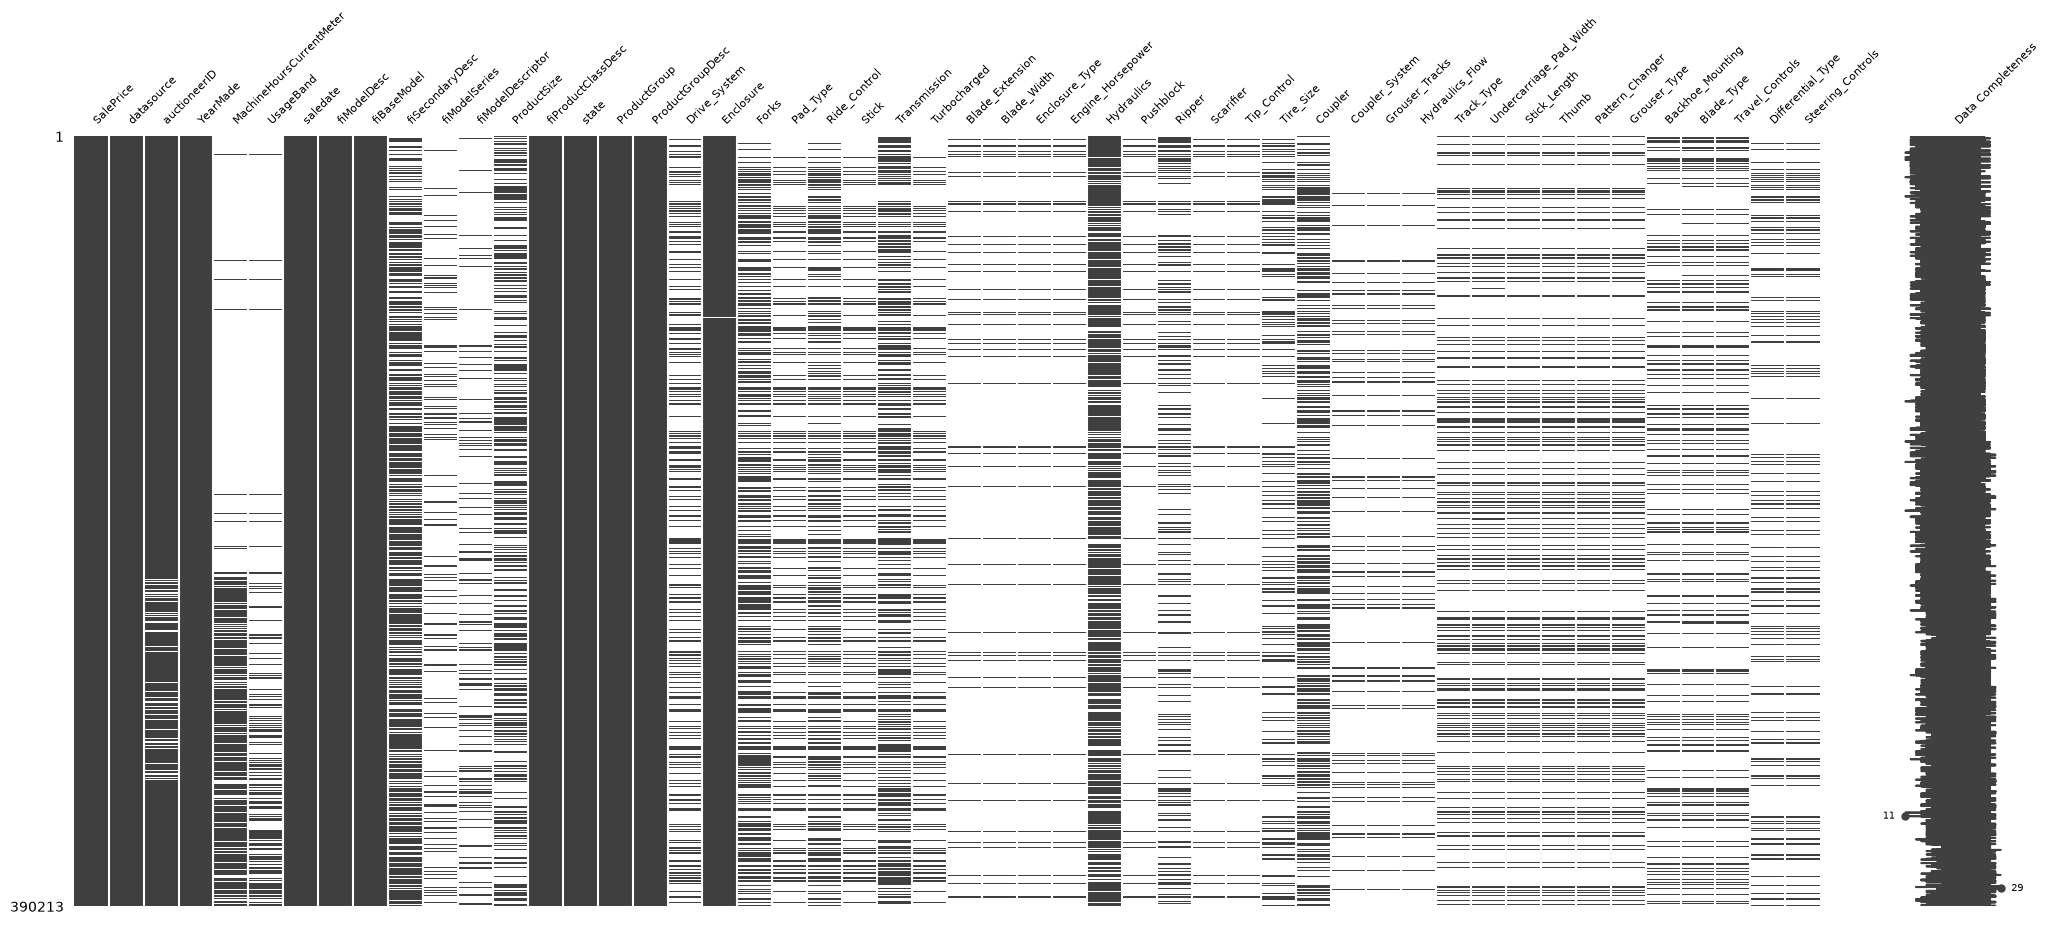

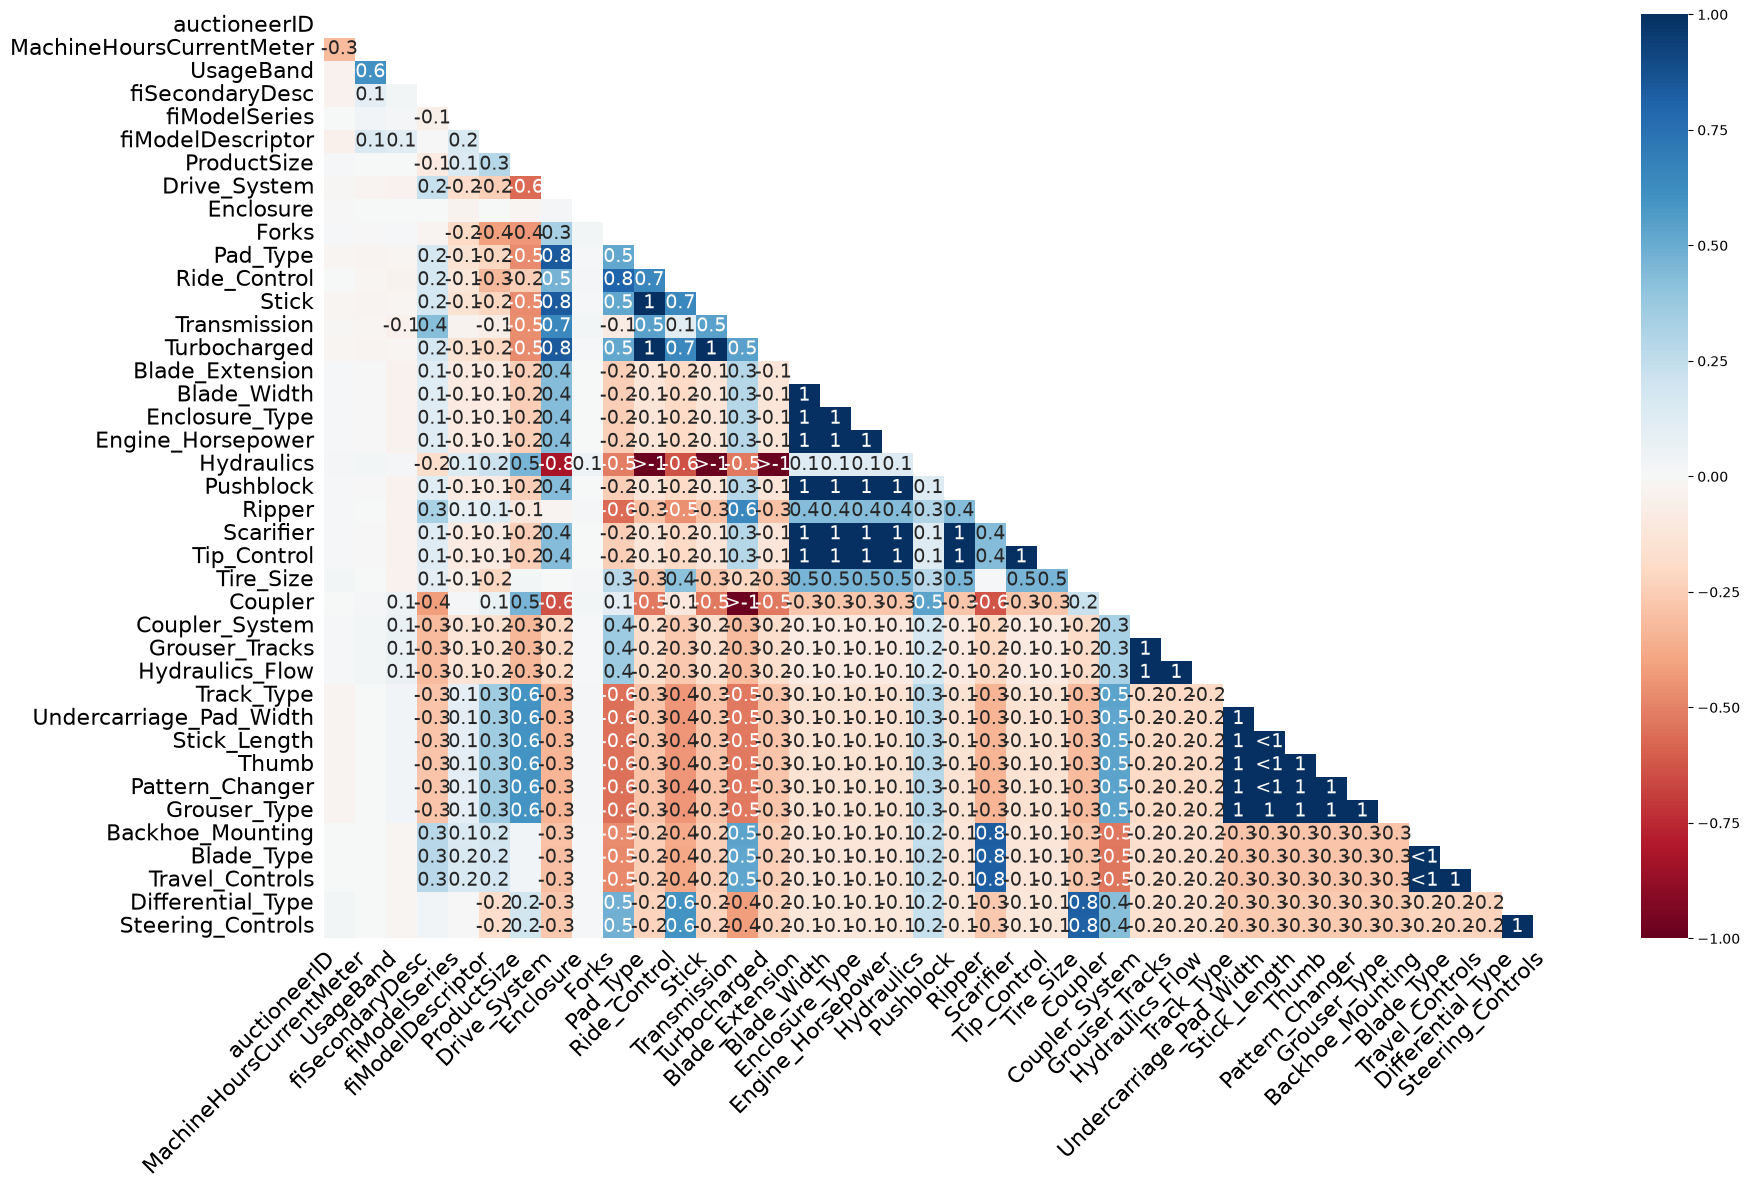

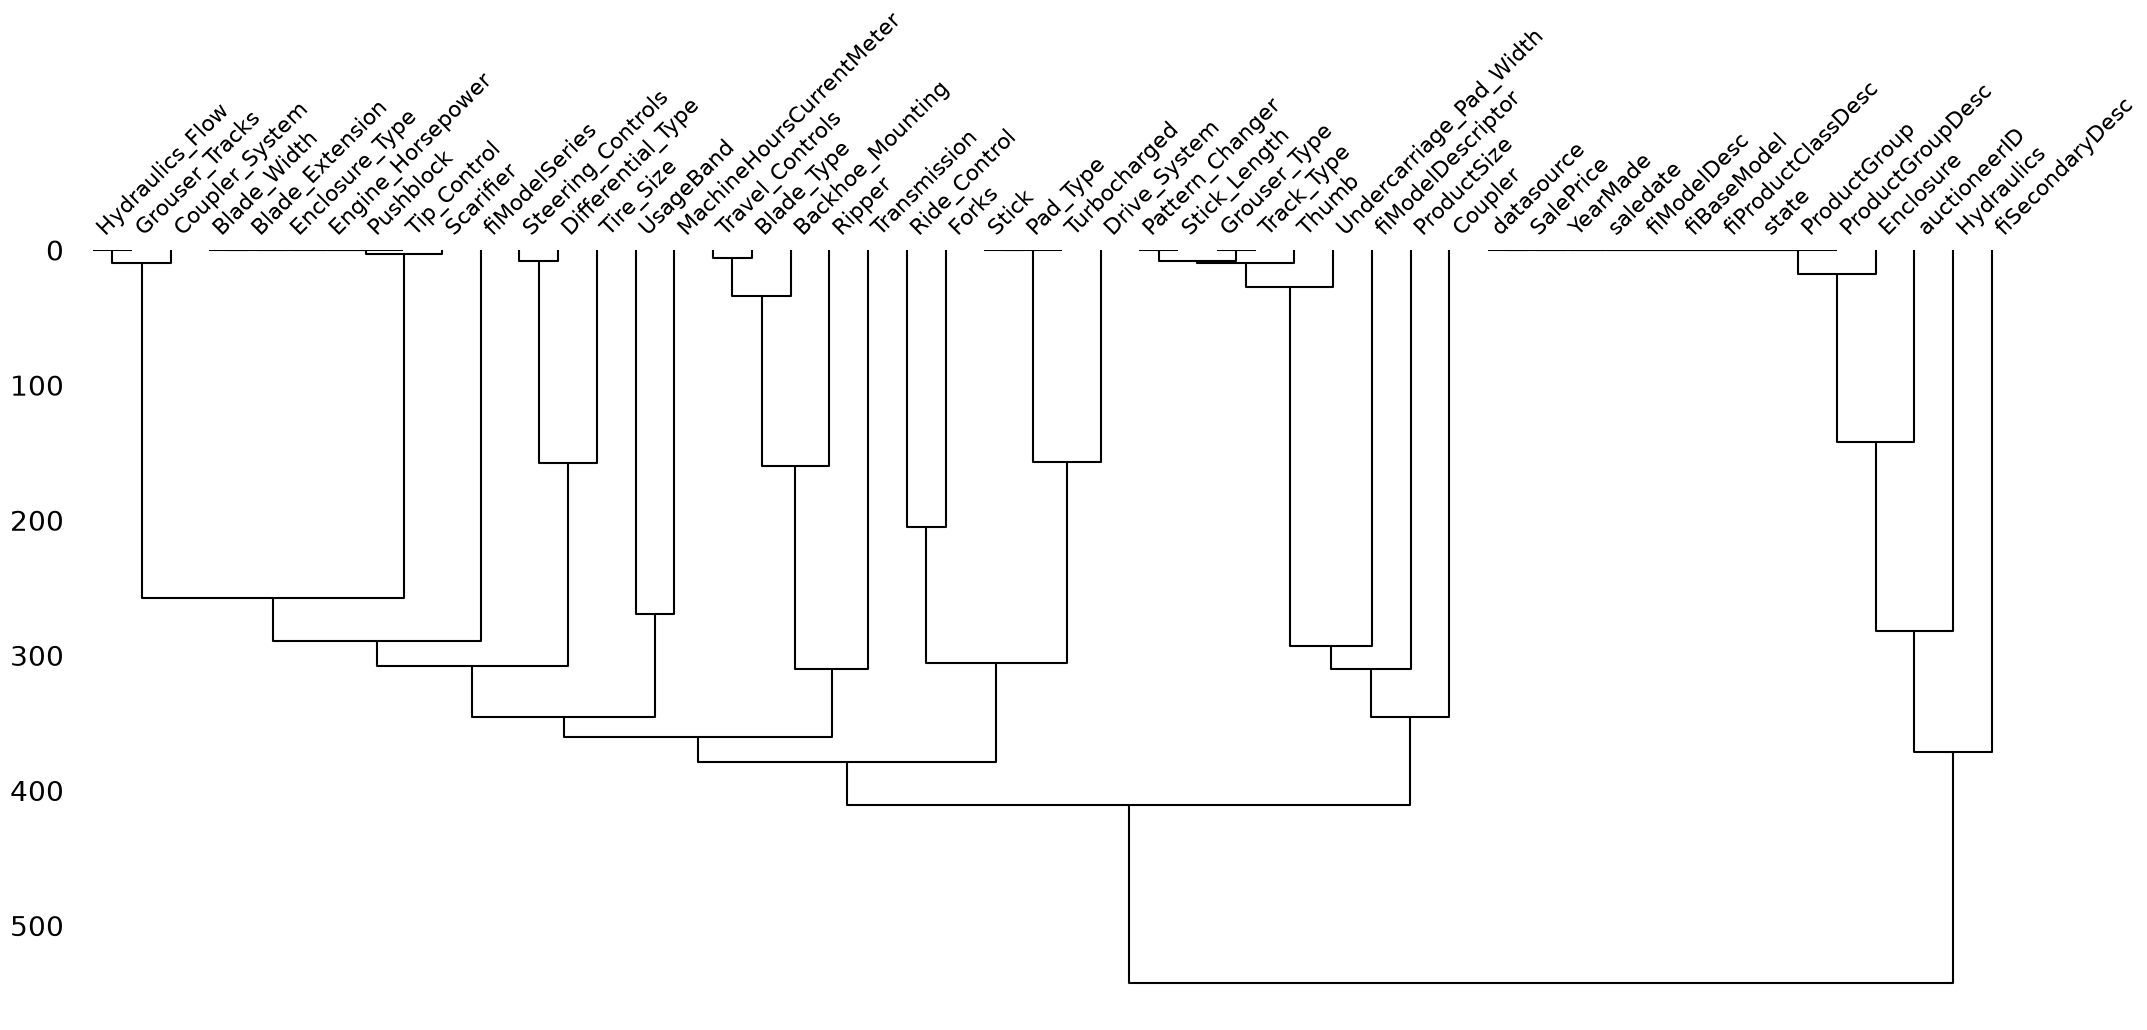

In [7]:
if AFFICHER_GRAPHIQUES:
    import missingno as msno
    import matplotlib.pyplot as plt
    
    msno.matrix(df.loc[idx_train_inner], labels=True, fontsize=8)
    plt.show()
    
    msno.heatmap(df.loc[idx_train_inner])
    plt.show()
    
    msno.dendrogram(df.loc[idx_train_inner])
    plt.show()

### Les modalités sont-elles exploitables ?

Avant d'imputer quoi que ce soit, on regarde à quoi ressemblent réellement les catégories : libellés proches, doublons de sens, valeurs sentinelles. Imputer d'abord reviendrait à figer des erreurs de saisie en modalités légitimes.

In [8]:
with pd.option_context("display.max_columns", None):
    print(df.loc[idx_train_inner].head(30))

        SalePrice datasource auctioneerID  YearMade  MachineHoursCurrentMeter  \
205615     9500.0        132         18.0      1974                       NaN   
28603      9500.0        132         18.0      1977                       NaN   
28757      8000.0        132         99.0      1978                       NaN   
28820      9000.0        132         18.0      1978                       NaN   
28927      7700.0        132         18.0      1978                       NaN   
31494     17000.0        132         99.0      1983                       NaN   
32138     20000.0        132         99.0      1984                       NaN   
32317     21000.0        132         99.0      1984                       NaN   
52508     35000.0        132         99.0      1978                       NaN   
53101     49000.0        132         99.0      1984                       NaN   
54181     21000.0        132         18.0      1972                       NaN   
54438     24000.0        132

In [9]:
df.loc[idx_train_inner]["ProductSize"].value_counts(dropna=False)

ProductSize
NaN               205374
Medium             60477
Large / Medium     48003
Small              25840
Mini               24009
Large              20575
Compact             5935
Name: count, dtype: int64

In [10]:
with pd.option_context("display.max_rows", None):
    print(df.loc[idx_train_inner]["fiProductClassDesc"].value_counts(dropna=False))

fiProductClassDesc
Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth             54895
Track Type Tractor, Dozer - 20.0 to 75.0 Horsepower                 17493
Wheel Loader - 150.0 to 175.0 Horsepower                            14778
Track Type Tractor, Dozer - 85.0 to 105.0 Horsepower                14301
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons               12879
Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons               11125
Track Type Tractor, Dozer - 130.0 to 160.0 Horsepower               10849
Track Type Tractor, Dozer - 260.0 + Horsepower                      10797
Backhoe Loader - 15.0 to 16.0 Ft Standard Digging Depth             10342
Wheel Loader - 120.0 to 135.0 Horsepower                            10243
Skid Steer Loader - 1351.0 to 1601.0 Lb Operating Capacity           9087
Skid Steer Loader - 1601.0 to 1751.0 Lb Operating Capacity           8724
Motorgrader - 145.0 to 170.0 Horsepower                              8650
Hydraulic Excavator

In [11]:
# --- ÉTAPE A : Extraire la spécification technique (après le tiret) ---
# On récupère tout ce qui se trouve après le premier " - "
df["spec_*"] = df["fiProductClassDesc"].str.split(" - ", n=1).str[1]

# --- ÉTAPE B : Suppression des colonnes redondantes ---
colonnes_a_supprimer = [
    "ProductGroupDesc"    # Redondant avec product group 
]
       

df = df.drop(columns=colonnes_a_supprimer)

In [12]:
with pd.option_context("display.max_rows", None): print(df.loc[idx_train_inner]["spec_*"].value_counts())

spec_*
14.0 to 15.0 Ft Standard Digging Depth    54895
20.0 to 75.0 Horsepower                   17493
150.0 to 175.0 Horsepower                 14778
85.0 to 105.0 Horsepower                  14301
21.0 to 24.0 Metric Tons                  12879
12.0 to 14.0 Metric Tons                  11125
130.0 to 160.0 Horsepower                 10849
260.0 + Horsepower                        10797
15.0 to 16.0 Ft Standard Digging Depth    10342
120.0 to 135.0 Horsepower                 10243
1351.0 to 1601.0 Lb Operating Capacity     9087
1601.0 to 1751.0 Lb Operating Capacity     8724
145.0 to 170.0 Horsepower                  8650
33.0 to 40.0 Metric Tons                   8376
160.0 to 190.0 Horsepower                  7297
175.0 to 200.0 Horsepower                  7290
1251.0 to 1351.0 Lb Operating Capacity     7244
6.0 to 8.0 Metric Tons                     7210
1751.0 to 2201.0 Lb Operating Capacity     7132
100.0 to 110.0 Horsepower                  6999
45.0 to 130.0 Horsepower         

### Une colonne numérique par unité de mesure

`fiProductClassDesc` mélange quatre unités incomparables  chevaux, tonnes métriques, pieds de profondeur, livres de capacité  dans un même texte. Les réunir dans une seule colonne numérique reviendrait à comparer des grandeurs sans rapport. On crée donc une colonne par unité, renseignée seulement quand l'unité correspond.

Les intervalles (« 14.0 to 15.0 ») sont ramenés à leur centre, les bornes ouvertes (« 260.0 + ») à leur borne basse. Ce sont des approximations assumées, pas des mesures.

In [13]:
# Repérer l'unité de mesure à partir du libellé.
conditions_unite = [
    df["spec_*"].str.contains("Horsepower", na=False),
    df["spec_*"].str.contains("Metric Tons", na=False),
    df["spec_*"].str.contains("Digging Depth", na=False),
    df["spec_*"].str.contains("Operating Capacity", na=False),
]
labels_unite = ["Horsepower", "Metric Tons", "Digging Depth (Ft)", "Lb Operating Capacity"]
df["spec_unit"] = np.select(conditions_unite, labels_unite, default="Unidentified")

# Extraire une ou deux bornes numériques : "14.0 to 15.0" en donne deux, "260.0 +" une seule.
bornes = df["spec_*"].str.extract(r"(\d+\.?\d*)(?:\s+to\s+(\d+\.?\d*))?")
borne_basse = bornes[0].astype(float)
borne_haute = bornes[1].astype(float)

# Valeur représentative : centre de l'intervalle, ou borne basse si l'intervalle est ouvert.
df["spec_value"] = np.where(borne_haute.notna(), (borne_basse + borne_haute) / 2, borne_basse)

In [14]:
# Une colonne par unité : la valeur si l'unité correspond, NaN sinon.
# Les quatre unités mesurent des grandeurs sans rapport entre elles.
for unite in labels_unite:
    colonne = "spec_" + unite.lower().replace(" ", "_").replace("(", "").replace(")", "")
    df[colonne] = np.where(df["spec_unit"] == unite, df["spec_value"], np.nan)

df = df.drop(columns=["spec_unit", "spec_value", "spec_*"])

Les quatre unités sont définies en dur par `labels_unite`, même si l'une venait à être absente de l'apprentissage : la composition des données ne décide donc pas des colonnes créées, et le schéma reste stable d'une fenêtre à l'autre.

### Contrôle des bornes numériques

On inspecte minimum, médiane et maximum de chaque variable numérique pour repérer les valeurs physiquement impossibles avant de décider d'un traitement.

In [15]:
with pd.option_context("display.max_rows", None):
    print(df.loc[idx_train_inner].select_dtypes(include="number").agg(["min", "median","max"]).T)

                               min   median        max
SalePrice                   4750.0  24000.0   142000.0
YearMade                    1000.0   1995.0     2012.0
MachineHoursCurrentMeter       0.0      0.0  2483300.0
spec_horsepower               20.0    142.5     1000.0
spec_metric_tons               1.0     17.5      300.0
spec_digging_depth_ft          7.0     14.5       16.0
spec_lb_operating_capacity   350.5   1676.0     2701.0


In [16]:
df = zero_vers_nan(df, "MachineHoursCurrentMeter")
df = transformation_binaire(df, "MachineHoursCurrentMeter", "hours_reported")
df = remplacer_au_dessus_seuil(df, "MachineHoursCurrentMeter", 40000)

In [17]:
df.loc[df["MachineHoursCurrentMeter"] < 0, "MachineHoursCurrentMeter"] = np.nan

In [18]:
manquantes = df.loc[idx_train_inner, "MachineHoursCurrentMeter"].isna().sum()
print(f"Compteur horaire manquant après nettoyage : {manquantes} ventes sur {len(idx_train_inner)}")

Compteur horaire manquant après nettoyage : 325522 ventes sur 390213


### `YearMade` : des valeurs incohérentes à neutraliser

In [19]:
with pd.option_context("display.max_rows",None):print(df.loc[idx_train_inner]["YearMade"].value_counts().sort_index())

YearMade
1000    37214
1919      123
1920       13
1937        1
1942        1
1947        1
1948        3
1949        1
1950        8
1951        7
1952        6
1953        6
1954        3
1955        5
1956       17
1957       15
1958       22
1959       28
1960       97
1961       98
1962      142
1963      241
1964      409
1965      662
1966      939
1967     1079
1968     1240
1969     1522
1970     1304
1971     1681
1972     2095
1973     2492
1974     3055
1975     3164
1976     2668
1977     4342
1978     5583
1979     5516
1980     4635
1981     4102
1982     2990
1983     4515
1984     6048
1985     6415
1986     7416
1987    10027
1988    10272
1989    10581
1990    10139
1991     7268
1992     7462
1993    10810
1994    13986
1995    15294
1996    16386
1997    18520
1998    20742
1999    18270
2000    16261
2001    12500
2002    11563
2003    13667
2004    19011
2005    19007
2006    11127
2007     4053
2008     1201
2009      120
2010       17
2011        4
2012       

#### Règle retenue

La valeur sentinelle `1000` et les années de fabrication postérieures à la vente ne permettent pas de calculer un âge cohérent.

**Action :** restriction à **[1950 ; année de vente]**. La borne basse 1950 est un choix de simplification, pas la preuve que toute machine plus ancienne soit une erreur de saisie. Une faible proportion de lignes concernées ne suffit pas à prouver un impact négligeable sur les prédictions : il faudrait comparer les scores avec et sans cette borne.

Les valeurs hors de cette fenêtre deviennent manquantes et seront imputées plus loin ; les ventes correspondantes sont conservées. La borne haute est l'année de vente de chaque ligne, ce qui interdit tout âge négatif.

In [20]:
df = nettoyer_hors_bornes(df, "YearMade", borne_min=1950, borne_max=df["saledate"].dt.year)

In [21]:
df_non_num=df.loc[idx_train_inner].select_dtypes(exclude="number")
nan_tot = df_non_num.isnull().sum()
colonnes_avec_nan= nan_tot[nan_tot>0].index


variablesgardees = variable_nan_structurel(df.loc[idx_train_inner], "ProductGroup", colonnes_avec_nan, 5, 95)
print(variablesgardees)
len(variablesgardees)

['Drive_System', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Steering_Controls']


32

`variablesgardees` est calculée sur l'apprentissage uniquement. Un taux de valeurs manquantes très élevé dans une famille suggère un mécanisme particulier  un équipement qui n'existe pas sur ce type de machine  mais ne le prouve pas. La méthode B reste une hypothèse à comparer à A, pas un fait métier établi.

### Passage au log du prix

Les prix de vente s'étalent de quelques milliers à plusieurs centaines de milliers d'euros, avec une forte asymétrie. On modélise `log1p(SalePrice)` : l'erreur quadratique sur cette cible est le **RMSLE** sur les prix, qui pénalise l'écart *relatif* plutôt que l'écart en euros. Une erreur de 2 000 € sur une machine à 10 000 € pèse alors davantage que la même erreur sur une machine à 200 000 €, ce qui correspond à l'usage visé.

In [22]:
df.loc[idx_train_inner]["SalePrice"].describe()

count    390213.000000
mean      31010.847450
std       22960.141465
min        4750.000000
25%       14500.000000
50%       24000.000000
75%       40000.000000
max      142000.000000
Name: SalePrice, dtype: float64

In [23]:
df["logSalePrice"] = np.log1p(df["SalePrice"])

### Deux représentations des absences à comparer

À partir d'ici, les traitements divergent. Les deux méthodes travaillent sur les mêmes lignes et les mêmes variables ; seule la façon de coder une valeur catégorielle manquante change :

- **Méthode A**  `Missing` uniforme ;
- **Méthode B**  `Absent dans ce segment` pour les absences quasi systématiques dans une famille, `Missing` pour les autres.

Le libellé de B décrit une règle statistique, pas une certitude métier.

In [24]:
df_methodeA = df.copy()
df_methodeB = df.copy()


## 2. Méthode A  une seule étiquette pour toute absence

*Toutes les cellules de ce bloc ne référencent que `df_methodeA`.*

A est la représentation la plus simple possible : toute valeur catégorielle manquante devient `Missing`. Elle sert de point de comparaison  si B n'apporte rien de mesurable, c'est A qu'on garde, par simplicité.

On commence par les colonnes repérées comme structurellement absentes dans certaines familles. En méthode A, elles reçoivent le même `Missing` que toutes les autres : c'est précisément ce que B remettra en cause.

In [25]:
for i in variablesgardees:
    df_methodeA.loc[df_methodeA[i].isna(), i] = "Missing"

### `UsageBand` : une catégorie conservée telle quelle

On conserve la catégorie renseignée dans le fichier. Quand elle manque, on impute `"Missing"`. Aucune moyenne n'est recalculée pour cette variable.

Le dictionnaire fourni avec les données la décrit comme un niveau d'usage relatif à la moyenne du même `fiBaseModel`, compte tenu de la durée de vie de la machine. On suppose ici que cette catégorie est disponible au moment de l'estimation. La période et la population utilisées par le fournisseur pour calculer la référence ne sont pas précisées : cette provenance reste une limite documentée, sans fuite démontrée.

In [26]:
rarelistA = ["ProductSize", "Forks", "Ride_Control", "Transmission", "Coupler"]

for col in rarelistA:
    df_methodeA[col] = df_methodeA[col].fillna("Missing")

mapping_enclosure = {"EROPS AC": "EROPS w AC", "None or Unspecified": np.nan}
df_methodeA["Enclosure"] = df_methodeA["Enclosure"].replace(mapping_enclosure)
df_methodeA["Enclosure"] = df_methodeA["Enclosure"].fillna("Missing")

df_methodeA["UsageBand"] = df_methodeA["UsageBand"].fillna("Missing")


df_methodeA.isnull().sum()

SalePrice                          0
datasource                         0
auctioneerID                   20136
YearMade                       38349
MachineHoursCurrentMeter      332074
UsageBand                          0
saledate                           0
fiModelDesc                        0
fiBaseModel                        0
fiSecondaryDesc               137191
fiModelSeries                 344217
fiModelDescriptor             329206
ProductSize                        0
fiProductClassDesc                 0
state                              0
ProductGroup                       0
Drive_System                       0
Enclosure                          0
Forks                              0
Pad_Type                           0
Ride_Control                       0
Stick                              0
Transmission                       0
Turbocharged                       0
Blade_Extension                    0
Blade_Width                        0
Enclosure_Type                     0
E

`NO ROPS` reste distinct d'`OROPS` : on ne suppose pas l'équivalence entre une absence de structure de protection et un poste ouvert qui en est équipé. Seuls `EROPS AC` et `EROPS w AC`, qui désignent la même configuration, sont fusionnés.

In [27]:
var_nan_non_structurel=["fiModelSeries","fiModelDescriptor","fiSecondaryDesc"]
for i in var_nan_non_structurel:
    df_methodeA[i]=df_methodeA[i].fillna("Missing") 

In [28]:
df_methodeA["auctioneerID"] = df_methodeA["auctioneerID"].fillna("Missing")

In [29]:
# Compléter les autres catégories manquantes, sans apprendre de statistique.
for col in df_methodeA.select_dtypes(include=["object", "string"]).columns:
    df_methodeA[col] = df_methodeA[col].fillna("Missing").astype(object)

### Variables dérivées (méthode A)

Composantes de date, âge, intensité d'usage, indicateur de récession et préfixe de modèle sont construits ici. Un arbre pourrait reconstituer l'âge à partir de l'année de vente et de l'année de fabrication, mais au prix de nombreuses coupures successives : lui donner la variable directement économise de la profondeur.

In [30]:
df_methodeA["sale_year"] = df_methodeA["saledate"].dt.year
df_methodeA["sale_month"] = df_methodeA["saledate"].dt.month
df_methodeA["sale_day"] = df_methodeA["saledate"].dt.day
df_methodeA["sale_quarter"] = df_methodeA["saledate"].dt.quarter


#### Âge de la machine

L'âge est calculé **avant** l'imputation de `YearMade`. Dans l'ordre inverse, une année imputée produirait un âge présenté comme observé.

In [31]:
df_methodeA["machine_age"]=df_methodeA["sale_year"]-df_methodeA["YearMade"]
print(df_methodeA["machine_age"])


205615    15.0
28603     12.0
28757     11.0
28820     11.0
28927     11.0
          ... 
400455     4.0
400457     3.0
400458     1.0
400459     1.0
401026    10.0
Name: machine_age, Length: 401125, dtype: float64


#### Intensité d'utilisation

Les heures au compteur rapportées au nombre d'années d'usage séparent une machine ancienne peu sollicitée d'une machine récente très employée  deux profils d'usure opposés que le seul compteur ne distingue pas.

Quand l'âge vaut 0, la division n'a pas de sens : le ratio reste manquant, puis prendra `-1` comme les autres variables dérivées.

In [32]:
df_methodeA["heures_par_an"]=df_methodeA["MachineHoursCurrentMeter"]/df_methodeA["machine_age"].where(df_methodeA["machine_age"] > 0)
print(df_methodeA["heures_par_an"])


205615   NaN
28603    NaN
28757    NaN
28820    NaN
28927    NaN
          ..
400455   NaN
400457   NaN
400458   NaN
400459   NaN
401026   NaN
Name: heures_par_an, Length: 401125, dtype: float64


Même logique que pour l'âge : le ratio `heures_par_an` est calculé avant le remplacement des valeurs non calculables par la sentinelle `-1`, pour la même raison — une valeur imputée ne doit pas se présenter comme si elle avait été observée.

#### Contexte macroéconomique

2008 et 2009 marquent un effondrement du marché des engins de chantier. L'indicateur donne au modèle un repère explicite, au lieu de lui faire déduire cet effet des seules composantes de date.

In [33]:
df_methodeA["is_recession"] = np.where(df_methodeA["sale_year"].isin([2008, 2009]), 1, 0)


#### Préfixe du modèle

Le préfixe alphabétique de `fiBaseModel`  « WA » dans « WA320 »  regroupe les machines d'une même gamme constructeur, information qu'un nom de modèle trop rare ne porterait pas à lui seul. Les noms purement numériques reçoivent `Numeric`.

In [34]:
# Préfixe alphabétique du modèle : "WA" dans "WA320", "Numeric" si le nom est purement numérique.
df_methodeA["model_prefix"] = (df_methodeA["fiBaseModel"]
                               .str.extract(r"^([A-Za-z]+)", expand=False)
                               .fillna("Numeric"))
print(df_methodeA["model_prefix"].value_counts(dropna=False))

model_prefix
Numeric    252569
D           61774
PC          16262
EX           9183
WA           7182
            ...  
KL              1
PRODIGY         1
SUPER           1
HW              1
KBD             1
Name: count, Length: 158, dtype: int64


In [36]:
nan_col_numA =["spec_horsepower","spec_lb_operating_capacity","spec_metric_tons","spec_digging_depth_ft","machine_age","heures_par_an"]
for col in nan_col_numA:
    df_methodeA[col]=df_methodeA[col].fillna(-1)

In [37]:
restantes = int(df_methodeA[nan_col_numA].isnull().sum().sum())
print(f"Valeurs manquantes restantes dans les variables dérivées (A) : {restantes}")

Valeurs manquantes restantes dans les variables dérivées (A) : 0


In [38]:
assert not np.isinf(df_methodeA["heures_par_an"]).any(), "Infini résiduel dans heures_par_an"
print("Aucun infini dans heures_par_an (A).")

Aucun infini dans heures_par_an (A).


## 3. Méthode B  distinguer les absences quasi systématiques

*Toutes les cellules de ce bloc ne référencent que `df_methodeB`.*

B fait une hypothèse : une absence concentrée dans une famille  plus de 95 % des lignes  ne relève probablement pas du même mécanisme qu'une absence isolée. La première ressemble à un équipement qui n'existe pas sur ce type de machine, la seconde à une information non saisie. B leur donne donc deux libellés distincts.

Savoir si cette distinction améliore réellement la prédiction n'est pas décidable ici : c'est l'objet du notebook 02.

La règle est **apprise sur l'apprentissage, puis appliquée telle quelle** à la validation : la composition de la période à prédire ne peut pas modifier le codage.

La fonction `imputer_valeurs_rares` d'origine calcule ses taux sur le DataFrame reçu. On lui passe donc **uniquement l'apprentissage**. Pour la validation, on applique explicitement les groupes repérés sur l'apprentissage, sans recalculer les taux.

In [39]:
rarelistB = ["ProductSize", "Forks", "Ride_Control", "Transmission", "Coupler"]
colonnes_imputationB = list(dict.fromkeys(list(variablesgardees) + rarelistB))

# Apprendre les groupes à modifier AVANT de remplir les valeurs manquantes.
groupes_absenceB = {}
for col in colonnes_imputationB:
    taux_nan = df_methodeB.loc[idx_train_inner].groupby("ProductGroup")[col].apply(lambda x: x.isnull().mean() * 100)
    groupes_absenceB[col] = taux_nan[taux_nan > 95].index

train_imputationB = imputer_valeurs_rares(df_methodeB.loc[idx_train_inner].copy(), "ProductGroup", colonnes_imputationB, 95, "Absent dans ce segment")
df_methodeB.loc[idx_train_inner, colonnes_imputationB] = train_imputationB[colonnes_imputationB]

for col in colonnes_imputationB:
    mask = df_methodeB.index.isin(idx_val) & df_methodeB["ProductGroup"].isin(groupes_absenceB[col]) & df_methodeB[col].isna()
    df_methodeB.loc[mask, col] = "Absent dans ce segment"
    df_methodeB[col] = df_methodeB[col].fillna("Missing")

mapping_enclosure = {"EROPS AC": "EROPS w AC", "None or Unspecified": np.nan}
df_methodeB["Enclosure"] = df_methodeB["Enclosure"].replace(mapping_enclosure)
df_methodeB["Enclosure"] = df_methodeB["Enclosure"].fillna("Missing")
df_methodeB["UsageBand"] = df_methodeB["UsageBand"].fillna("Missing")

### `ProductSize` : d'où viennent les absences ?

On examine les taux de valeurs manquantes par source et par commissaire-priseur. Une différence de taux signale une origine possible, elle ne démontre pas une cause unique.

En A, ces valeurs deviennent `Missing`. En B, `ProductSize` fait partie de `rarelistB` : les familles dépassant 95 % d'absence sur l'apprentissage reçoivent le libellé d'absence, les autres `Missing`.

In [40]:
print(df.loc[idx_train_inner]["ProductSize"].value_counts(dropna=False))

ProductSize
NaN               205374
Medium             60477
Large / Medium     48003
Small              25840
Mini               24009
Large              20575
Compact             5935
Name: count, dtype: int64


In [41]:
print(df.loc[idx_train_inner]["Enclosure"].value_counts(dropna=False))

Enclosure
OROPS                  170524
EROPS                  136435
EROPS w AC              82912
NaN                       320
EROPS AC                   17
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64


In [42]:
with pd.option_context("display.max_rows",None):(print(df.loc[idx_train_inner].groupby("datasource")["ProductSize"].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)))

datasource
149    64.524232
132    52.794285
136    51.788955
121    50.431131
172    37.590086
Name: ProductSize, dtype: float64


In [43]:
with pd.option_context("display.max_rows",None):(print(df.loc[idx_train_inner].groupby("auctioneerID")["ProductSize"].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)))

auctioneerID
25.0    71.949948
18.0    71.343790
26.0    65.828402
21.0    64.896939
22.0    63.470959
14.0    63.148637
20.0    63.047364
28.0    62.558140
11.0    59.639027
99.0    58.501311
12.0    58.108108
27.0    56.000000
0.0     55.955679
8.0     55.299410
10.0    55.139373
13.0    53.607897
2.0     52.777028
7.0     52.767857
9.0     52.518892
1.0     51.920601
3.0     51.084425
17.0    50.745098
6.0     50.192469
4.0     50.154027
23.0    49.092284
16.0    47.742664
19.0    46.673095
24.0    45.910096
15.0    45.069570
5.0     39.959314
Name: ProductSize, dtype: float64


In [44]:
# 1. Taux de NaN par fiBaseModel (déjà fait, rappelé ici)
taux_nan_par_modele = df.loc[idx_train_inner].groupby("fiBaseModel")["fiModelDescriptor"].apply(
    lambda x: x.isna().mean() * 100
)

# 2. Nombre de lignes par fiBaseModel
effectif_par_modele = df.loc[idx_train_inner]["fiBaseModel"].value_counts()

# 3. Classement quasi-binaire vs intermédiaire
categorie_modele = pd.cut(
    taux_nan_par_modele,
    bins=[-0.01, 5, 95, 100],
    labels=["quasi_nul", "intermediaire", "quasi_total"]
)

# 4. Proportion du total des LIGNES (pas des groupes) tombant en intermédiaire
resultat = pd.DataFrame({
    "taux_nan": taux_nan_par_modele,
    "effectif": effectif_par_modele,
    "categorie": categorie_modele
})

lignes_intermediaires = resultat.loc[resultat["categorie"] == "intermediaire", "effectif"].sum()
lignes_totales = resultat["effectif"].sum()
proportion_intermediaire = lignes_intermediaires / lignes_totales * 100

print(f"Nombre de fiBaseModel intermédiaires : {(resultat['categorie'] == 'intermediaire').sum()} sur {resultat.shape[0]}")
print(f"Lignes concernées par ces modèles intermédiaires : {lignes_intermediaires} sur {lignes_totales} ({proportion_intermediaire:.2f}%)")

Nombre de fiBaseModel intermédiaires : 217 sur 1935
Lignes concernées par ces modèles intermédiaires : 122792 sur 390213 (31.47%)


In [45]:
for col in ["datasource", "auctioneerID"]:
    taux = df.loc[idx_train_inner].groupby(col)["fiModelDescriptor"].apply(lambda x: x.isna().mean() * 100)
    print(f"--- {col} ---")
    print(f"min: {taux.min():.1f}% / max: {taux.max():.1f}%")

--- datasource ---
min: 66.2% / max: 86.1%
--- auctioneerID ---
min: 65.9% / max: 96.8%


`fiSecondaryDesc`, `fiModelSeries` et `fiModelDescriptor` sont diagnostiqués par modèle et par source. Les effectifs sont recalculés sur l'apprentissage de cette fenêtre : on ne reprend pas des chiffres calculés sur une autre période. Les valeurs encore manquantes après la règle B sont imputées par `Missing`.

In [46]:
df_methodeB["auctioneerID"] = df_methodeB["auctioneerID"].fillna("Missing")

In [47]:
var_nan_non_structurel=["fiModelSeries","fiModelDescriptor","fiSecondaryDesc"]
for i in var_nan_non_structurel:
    df_methodeB[i]=df_methodeB[i].fillna("Missing") 

In [48]:
for col in df_methodeB.select_dtypes(include=["object", "string"]).columns:
    df_methodeB[col] = df_methodeB[col].fillna("Missing").astype(object)

### Variables dérivées (méthode B)

Strictement les mêmes calculs que pour A. Seule la représentation des absences catégorielles distingue les deux méthodes : c'est la condition pour que la comparaison de 02 mesure bien cet effet-là, et pas un autre.

In [49]:
df_methodeB["sale_year"] = df_methodeB["saledate"].dt.year
df_methodeB["sale_month"] = df_methodeB["saledate"].dt.month
df_methodeB["sale_day"] = df_methodeB["saledate"].dt.day
df_methodeB["sale_quarter"] = df_methodeB["saledate"].dt.quarter


#### Âge de la machine

Même règle qu'en A : calculé avant l'imputation de `YearMade`.

In [50]:
df_methodeB["machine_age"]=df_methodeB["sale_year"]-df_methodeB["YearMade"]
print(df_methodeB["machine_age"])


205615    15.0
28603     12.0
28757     11.0
28820     11.0
28927     11.0
          ... 
400455     4.0
400457     3.0
400458     1.0
400459     1.0
401026    10.0
Name: machine_age, Length: 401125, dtype: float64


In [51]:
df_methodeB.loc[idx_train_inner, ["YearMade","machine_age","sale_year"]].corr()

,YearMade,machine_age,sale_year
YearMade,1.000000,-0.795199,0.630317
machine_age,-0.795199,1.000000,-0.030497
sale_year,0.630317,-0.030497,1.000000


#### Redondance assumée entre `YearMade`, `machine_age` et `sale_year`

La corrélation est mécanique : `machine_age = sale_year - YearMade`. Les trois variables sont conservées car l'âge évite aux arbres de reconstruire la relation par coupures successives. En contrepartie, cette redondance répartit l'importance entre les trois colonnes et rend leur interprétation individuelle trompeuse.

#### Intensité d'utilisation

Même calcul qu'en A, y compris le traitement de l'âge nul.

In [52]:
df_methodeB["heures_par_an"]=df_methodeB["MachineHoursCurrentMeter"]/df_methodeB["machine_age"].where(df_methodeB["machine_age"] > 0)
print(df_methodeB["heures_par_an"])


205615   NaN
28603    NaN
28757    NaN
28820    NaN
28927    NaN
          ..
400455   NaN
400457   NaN
400458   NaN
400459   NaN
401026   NaN
Name: heures_par_an, Length: 401125, dtype: float64


#### Contexte macroéconomique

Même indicateur de récession qu'en A.

In [53]:
df_methodeB["is_recession"] = np.where(df_methodeB["sale_year"].isin([2008, 2009]), 1, 0)


#### Préfixe du modèle

Même extraction qu'en A.

In [54]:
# Même règle qu'en méthode A.
df_methodeB["model_prefix"] = (df_methodeB["fiBaseModel"]
                               .str.extract(r"^([A-Za-z]+)", expand=False)
                               .fillna("Numeric"))
print(df_methodeB["model_prefix"].value_counts(dropna=False))

model_prefix
Numeric    252569
D           61774
PC          16262
EX           9183
WA           7182
            ...  
KL              1
PRODIGY         1
SUPER           1
HW              1
KBD             1
Name: count, Length: 158, dtype: int64


In [56]:
nan_col_numB =["spec_horsepower","spec_lb_operating_capacity","spec_metric_tons","spec_digging_depth_ft","machine_age","heures_par_an"]
for col in nan_col_numB:
    df_methodeB[col]=df_methodeB[col].fillna(-1)


In [57]:
restantes = int(df_methodeB[nan_col_numB].isnull().sum().sum())
print(f"Valeurs manquantes restantes dans les variables dérivées (B) : {restantes}")

Valeurs manquantes restantes dans les variables dérivées (B) : 0


In [58]:
assert not np.isinf(df_methodeB["heures_par_an"]).any(), "Infini résiduel dans heures_par_an"
print("Aucun infini dans heures_par_an (B).")

Aucun infini dans heures_par_an (B).


## 4. Split temporel et statistiques apprises sur l'apprentissage

À partir d'ici, chaque statistique  fréquences de modèle, regroupement des catégories rares, médianes d'imputation  est calculée sur l'apprentissage puis appliquée à la validation. C'est le point où se joue la prévention des fuites : une médiane calculée sur l'ensemble des données donnerait au modèle une information sur la période qu'il est censé prédire.

`trainA`/`trainB` contiennent maintenant l'apprentissage seulement. `valA`/`valB` contiennent la validation antérieure à 2012.

Les fonctions utilitaires (`regrouper_categories_rares`, `imputation_mediane_a_nan`, etc.) nomment leur second paramètre `test` dans leur signature; mais dans les appels ci-dessous, c'est bien `valA`/`valB` qui leur est passé : il s'agit de la validation, pas d'un jeu de test final. Le nom du paramètre ne reflète pas cet usage ; les fonctions elles-mêmes restent inchangées.

In [59]:
trainA = df_methodeA.loc[idx_train_inner].copy()
valA = df_methodeA.loc[idx_val].copy()

trainB = df_methodeB.loc[idx_train_inner].copy()
valB = df_methodeB.loc[idx_val].copy()

### Fréquence observée du modèle

`model_frequency` compte les occurrences de `fiBaseModel` dans le jeu utilisé pour ajuster cette transformation. Cette variable décrit la fréquence du modèle dans l’échantillon de ventes ; elle ne mesure ni la disponibilité des pièces ni la réparabilité. Une interprétation en termes de réparabilité nécessiterait une validation métier externe.


In [60]:
trainA["model_frequency"] = trainA["fiBaseModel"].map(trainA["fiBaseModel"].value_counts())
trainB["model_frequency"] = trainB["fiBaseModel"].map(trainB["fiBaseModel"].value_counts())


valA["model_frequency"] = valA["fiBaseModel"].map(trainA["fiBaseModel"].value_counts()).fillna(0)
valB["model_frequency"] = valB["fiBaseModel"].map(trainB["fiBaseModel"].value_counts()).fillna(0)

In [61]:
# 4. Transformations sur apprentissage/validation séparés (pour éviter la fuite de données)
trainA, valA = regrouper_categories_rares(trainA, valA, "Hydraulics", 500)


In [62]:
# 4. Transformations sur apprentissage/validation séparés (pour éviter la fuite de données)
trainB, valB = regrouper_categories_rares(trainB, valB, "Hydraulics", 500)


### Imputation médiane groupée : `YearMade` / `MachineHoursCurrentMeter`

Les masques de valeurs manquantes (`_was_nan`) sont sauvegardés avant imputation : une fois la valeur manquante remplacée par une médiane, elle devient indiscernable d'une valeur réellement observée, et le modèle ne pourrait plus faire la différence sans ce flag. Pour chaque variable, la médiane de `ProductGroup` est utilisée lorsque le groupe possède au moins **30 valeurs observées** ; sinon, la fonction utilise la médiane globale du jeu d'apprentissage fourni.

Le seuil de 30 est une convention pratique de repli, commune aux méthodes A et B, et non une garantie statistique universelle de stabilité de la médiane. Il reste à évaluer si des groupes peu renseignés apparaissent dans les fenêtres d'apprentissage. Les médianes et les effectifs doivent être ajustés exclusivement sur l'apprentissage de chaque découpage.

In [63]:
# Méthode A
for col in ["YearMade", "MachineHoursCurrentMeter"]:
    trainA[f"{col}_was_nan"] = trainA[col].isna().astype(int)
    valA[f"{col}_was_nan"] = valA[col].isna().astype(int)

trainA, valA = imputation_mediane_a_nan(trainA, valA, "ProductGroup", "YearMade", 30)
trainA, valA = imputation_mediane_a_nan(trainA, valA, "ProductGroup", "MachineHoursCurrentMeter", 30)

In [64]:
# Méthode B
for col in ["YearMade", "MachineHoursCurrentMeter"]:
    trainB[f"{col}_was_nan"] = trainB[col].isna().astype(int)
    valB[f"{col}_was_nan"] = valB[col].isna().astype(int)

trainB, valB = imputation_mediane_a_nan(trainB, valB, "ProductGroup", "YearMade", 30)
trainB, valB = imputation_mediane_a_nan(trainB, valB, "ProductGroup", "MachineHoursCurrentMeter", 30)


## 5. Construction de X et y

On réutilise `split_X_y`. CatBoost accepte les catégories textuelles : les copies encodées pour scikit-learn et XGBoost ne sont pas nécessaires ici.

La cible, le prix brut et la date complète sont exclus de X. Les composantes de date créées plus haut, elles, restent des variables explicatives.

Les assertions qui suivent sont le filet de sécurité du notebook : absence de cible dans X, aucune valeur manquante, aucun infini, colonnes et index alignés entre A et B, et surtout séparation temporelle stricte entre apprentissage et validation.

In [ ]:
X_trainA, y_trainA, X_valA, y_valA, X_trainB, y_trainB, X_valB, y_valB = split_X_y(trainA, valA, trainB, valB, "logSalePrice", ["saledate", "SalePrice"])

for X in [X_trainA, X_valA, X_trainB, X_valB]:
    assert not {"SalePrice", "logSalePrice", "saledate"}.intersection(X.columns)
    assert not X.isna().any().any(), "Il reste des valeurs manquantes"
    assert np.isfinite(X.select_dtypes(include="number")).all().all()
    assert ((X["machine_age"] >= 0) | (X["machine_age"] == -1)).all()
assert X_trainA.columns.equals(X_valA.columns)
assert X_trainA.columns.equals(X_trainB.columns)
assert X_trainB.columns.equals(X_valB.columns)
assert X_trainA.index.equals(X_trainB.index)
assert X_valA.index.equals(X_valB.index)
assert X_trainA.index.intersection(X_valA.index).empty
assert trainA["saledate"].max() < valA["saledate"].min()
assert valA["saledate"].max() < pd.Timestamp("2012-01-01")
print("Contrôles de préparation OK")
print(X_trainA.shape, X_valA.shape, X_trainB.shape, X_valB.shape)

Contrôles de préparation OK
(390213, 63) (10912, 63) (390213, 63) (10912, 63)


## 6. Export vers le notebook d'expériences

Exécuter cette cellule après les contrôles, puis ouvrir `02 - Experiences.ipynb` avec la même valeur de `FENETRE`. Les deux notebooks n'ont pas besoin de partager le même noyau (le processus Python qui exécute le code d'un notebook, propre à chaque fichier ouvert) : les données transitent par le fichier ci-dessous.

Pour la fenêtre de confirmation, régler `FENETRE = "confirmation"` en tête et réexécuter **tout** ce notebook  médianes, fréquences et règles B seront ainsi recalculées sur les seules ventes antérieures à janvier 2011. Réexécuter l'export après toute modification de la préparation.

In [66]:
dossier_preparation = ROOT / "resultats/notebooks_03" / FENETRE
dossier_preparation.mkdir(parents=True, exist_ok=True)
pd.to_pickle({"trainA": trainA, "valA": valA, "trainB": trainB, "valB": valB,
              "fenetre": FENETRE, "cutoff_val": cutoff_val, "fin_validation": fin_validation},
             dossier_preparation / "preparation.pkl.gz")
print("Préparation enregistrée :", dossier_preparation / "preparation.pkl.gz")

Préparation enregistrée : c:\Users\Abram\Desktop\Fiche\Projet\resultats\notebooks_03\principal\preparation.pkl.gz
